[*********************100%***********************]  3 of 3 completed


Ticker         D05.SI     O39.SI     S68.SI
Date                                       
2025-07-28  45.987095  16.261250  15.415151
2025-07-29  45.930389  16.204193  15.385845
2025-07-30  45.609066  16.204193  15.346768
2025-07-31  45.278294  16.042532  15.630064
2025-08-01  44.985321  15.966455  15.542145
2025-08-04  45.259388  16.071060  15.678907
2025-08-05  45.590168  16.147137  15.913362
2025-08-06  46.166653  16.204193  15.903590
2025-08-07  47.017220  16.251740  15.962203
2025-08-08  47.952839  16.358917  15.649603

Annual Returns (%) — Jul 2025 to Jul 2026
Ticker
D05.SI    60.72
O39.SI    77.91
S68.SI    55.89
dtype: float64

DBS — Last 5 days of Moving Averages
20-day MA:
Date
2026-07-22    69.234001
2026-07-23    69.605501
2026-07-24    70.031001
2026-07-27    70.448501
2026-07-28    70.874001
Name: D05.SI, dtype: float64

50-day MA:
Date
2026-07-22    65.5718
2026-07-23    65.8438
2026-07-24    66.1200
2026-07-27    66.4036
2026-07-28    66.6666
Name: D05.SI, dtype: float64


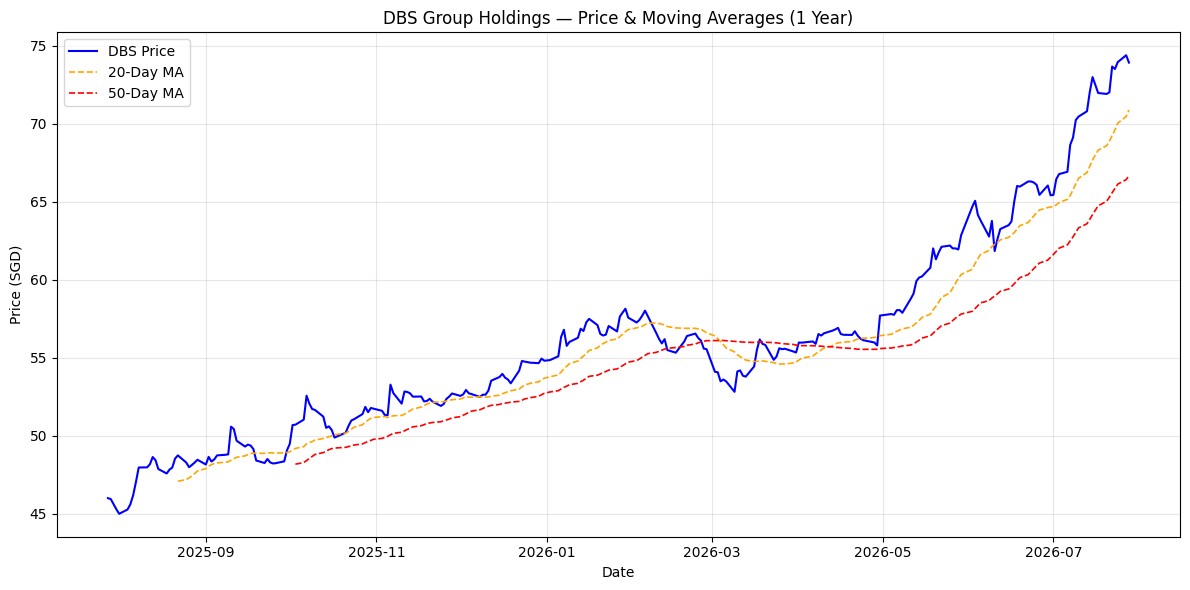

SGX STOCK PORTFOLIO TRACKER — SUMMARY

Period: 2025-07-28 to 2026-07-28

Annual Returns:
  D05.SI: +60.72%
  O39.SI: +77.91%
  S68.SI: +55.89%

Current Prices (SGD):
  D05.SI: S$73.91
  O39.SI: S$28.93
  S68.SI: S$24.03

DBS Moving Averages (latest):
  20-day MA: S$70.87
  50-day MA: S$66.67
  Signal: BULLISH — 20MA above 50MA


In [19]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Download 1 year of data for DBS, OCBC, SGX
tickers = ['D05.SI', 'O39.SI', 'S68.SI']
data = yf.download(tickers, period='1y', auto_adjust=True)['Close']

# Show the data
print(data.head(10))
print()

start_price = data.iloc[0]
end_price = data.iloc[-1]
returns = (end_price - start_price) / start_price * 100

print("Annual Returns (%) — Jul 2025 to Jul 2026")
print(returns.round(2))
print()

# 20-day and 50-day moving averages for DBS
dbs = data['D05.SI']
dbs_20ma = dbs.rolling(window=20).mean()
dbs_50ma = dbs.rolling(window=50).mean()

print("DBS — Last 5 days of Moving Averages")
print("20-day MA:")
print(dbs_20ma.tail())
print()
print("50-day MA:")
print(dbs_50ma.tail())

# Plot DBS price with moving averages
plt.figure(figsize=(12, 6))
plt.plot(dbs, label='DBS Price', linewidth=1.5, color='blue')
plt.plot(dbs_20ma, label='20-Day MA', linestyle='--', 
         linewidth=1.2, color='orange')
plt.plot(dbs_50ma, label='50-Day MA', linestyle='--', 
         linewidth=1.2, color='red')
plt.title('DBS Group Holdings — Price & Moving Averages (1 Year)')
plt.xlabel('Date')
plt.ylabel('Price (SGD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Full portfolio summary
print("=" * 45)
print("SGX STOCK PORTFOLIO TRACKER — SUMMARY")
print("=" * 45)
print(f"\nPeriod: {data.index[0].date()} to {data.index[-1].date()}")
print("\nAnnual Returns:")
for ticker, ret in returns.items():
    print(f"  {ticker}: {ret:+.2f}%")

print("\nCurrent Prices (SGD):")
for ticker, price in data.iloc[-1].items():
    print(f"  {ticker}: S${price:.2f}")

print("\nDBS Moving Averages (latest):")
print(f"  20-day MA: S${dbs_20ma.iloc[-1]:.2f}")
print(f"  50-day MA: S${dbs_50ma.iloc[-1]:.2f}")
print(f"  Signal: ", end="")
if dbs_20ma.iloc[-1] > dbs_50ma.iloc[-1]:
    print("BULLISH — 20MA above 50MA")
else:
    print("BEARISH — 20MA below 50MA")
print("=" * 45)